In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import seisbench.models as sbm
import torch
import numpy as np
import obspy
from typing import Any

In [3]:
model_base = sbm.PhaseNet(sampling_rate=400)

In [4]:
class DynamicWaveformModel(sbm.WaveformModel):
    def __init__(self):
        super().__init__(
            component_order="ZNE",
            output_type="array",
            in_samples=1024,
            pred_sample=(0, 1024),
            labels="PSN",
            sampling_rate=100,
        )

        self.layer = torch.nn.Linear(5, 5)

    def forward(self, x):
        return torch.ones((x.shape[0], 3, x.shape[-1]))

    def _get_in_pred_samples(self, block: np.ndarray) -> tuple[int, tuple[int, int]]:
        print(f"Called with: {block.shape}") 
        in_samples = 2 ** int(np.log2(block.shape[-1]))  # The largest power of 2 below the block shape
        in_samples = min(max(in_samples, 2 ** 10), 2 ** 20)  # Enforce upper and lower bounds
        pred_sample = (0, in_samples)
        print(in_samples, pred_sample)
        return in_samples, pred_sample

    def annotate_batch_post(
        self, batch: torch.Tensor, piggyback: Any, argdict: dict[str, Any]
    ) -> torch.Tensor:
        # Transpose predictions to correct shape
        return torch.transpose(batch, -1, -2)

In [5]:
model = DynamicWaveformModel()

In [6]:
x = torch.rand(10, 3, 50000)
model(x).shape

torch.Size([10, 3, 50000])

In [7]:
# stream = obspy.read()

n = 1000
header_base = {"network": "XX", "station": "YY", "location": "", "sampling_rate": 100}
stream = obspy.Stream([
    obspy.Trace(np.random.randn(n), header={**header_base, "channel": f"HH{c}"}) for c in model.component_order
])

model.annotate(stream)

2025-06-29 17:24:42,451 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.


0 Trace(s) in Stream:


In [8]:
header_base = {"network": "XX", "station": "YY", "location": "", "sampling_rate": model.sampling_rate}
stream1 = obspy.Stream([
    obspy.Trace(np.random.randn(2001), header={**header_base, "channel": f"HH{c}"}) for c in model.component_order
])
header_base = {"network": "XX", "station": "ZZ", "location": "", "sampling_rate": model.sampling_rate}
stream2 = obspy.Stream([
    obspy.Trace(np.random.randn(10000), header={**header_base, "channel": f"HH{c}"}) for c in model.component_order
])
model.annotate(stream1 + stream2)

Called with: (3, 2001)
1024 (0, 1024)
Called with: (3, 10000)
8192 (0, 8192)


6 Trace(s) in Stream:
XX.YY..DynamicWaveformModel_P | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.000000Z | 100.0 Hz, 2001 samples
XX.YY..DynamicWaveformModel_S | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.000000Z | 100.0 Hz, 2001 samples
XX.YY..DynamicWaveformModel_N | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.000000Z | 100.0 Hz, 2001 samples
XX.ZZ..DynamicWaveformModel_P | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:39.990000Z | 100.0 Hz, 10000 samples
XX.ZZ..DynamicWaveformModel_S | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:39.990000Z | 100.0 Hz, 10000 samples
XX.ZZ..DynamicWaveformModel_N | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:39.990000Z | 100.0 Hz, 10000 samples

## PhaseNetPlus

In [3]:
import sys

In [4]:
sys.path.append("/home/muchmej/code/EQNet/")

In [7]:
from eqnet.models.sb_model import PhaseNet

In [9]:
model = PhaseNet(sampling_rate=100, default_args={"blinding": (200, 200)})
# model.load_state_dict(torch.load("/home/muchmej/code/EQNet/models/model_99.pth", map_location=torch.device('cpu'))["model"])

In [10]:
stream = obspy.read("/home/muchmej/misc/sb_catalog_iquique_v2/data/waveforms/CX.PATCX..HH*__20140402T000000Z__20140403T000000Z.mseed")
t = stream[0].stats.starttime
stream = stream.slice(t, t + 3000)

In [11]:
stream = obspy.read()

In [12]:
ann = model.annotate(stream)
ann

6 Trace(s) in Stream:
BW.RJOB..PhaseNet_N            | 2009-08-24T00:20:03.000000Z - 2009-08-24T00:20:32.990000Z | 100.0 Hz, 3000 samples
BW.RJOB..PhaseNet_P            | 2009-08-24T00:20:03.000000Z - 2009-08-24T00:20:32.990000Z | 100.0 Hz, 3000 samples
BW.RJOB..PhaseNet_S            | 2009-08-24T00:20:03.000000Z - 2009-08-24T00:20:32.990000Z | 100.0 Hz, 3000 samples
BW.RJOB..PhaseNet_Polarity     | 2009-08-24T00:20:03.000000Z - 2009-08-24T00:20:32.990000Z | 100.0 Hz, 3000 samples
BW.RJOB..PhaseNet_Event center | 2009-08-24T00:20:03.000000Z - 2009-08-24T00:20:32.990000Z | 100.0 Hz, 3000 samples
BW.RJOB..PhaseNet_Event time   | 2009-08-24T00:20:03.000000Z - 2009-08-24T00:20:32.990000Z | 100.0 Hz, 3000 samples

In [13]:
model.classify(stream, P_threshold=0.1, S_threshold=0.1)

namespace(creator='PhaseNet',
          picks=PickList with 2 entries:
                
                BW.RJOB.	2009-08-24T00:20:12.860000Z	P
                BW.RJOB.	2009-08-24T00:20:11.260000Z	S)

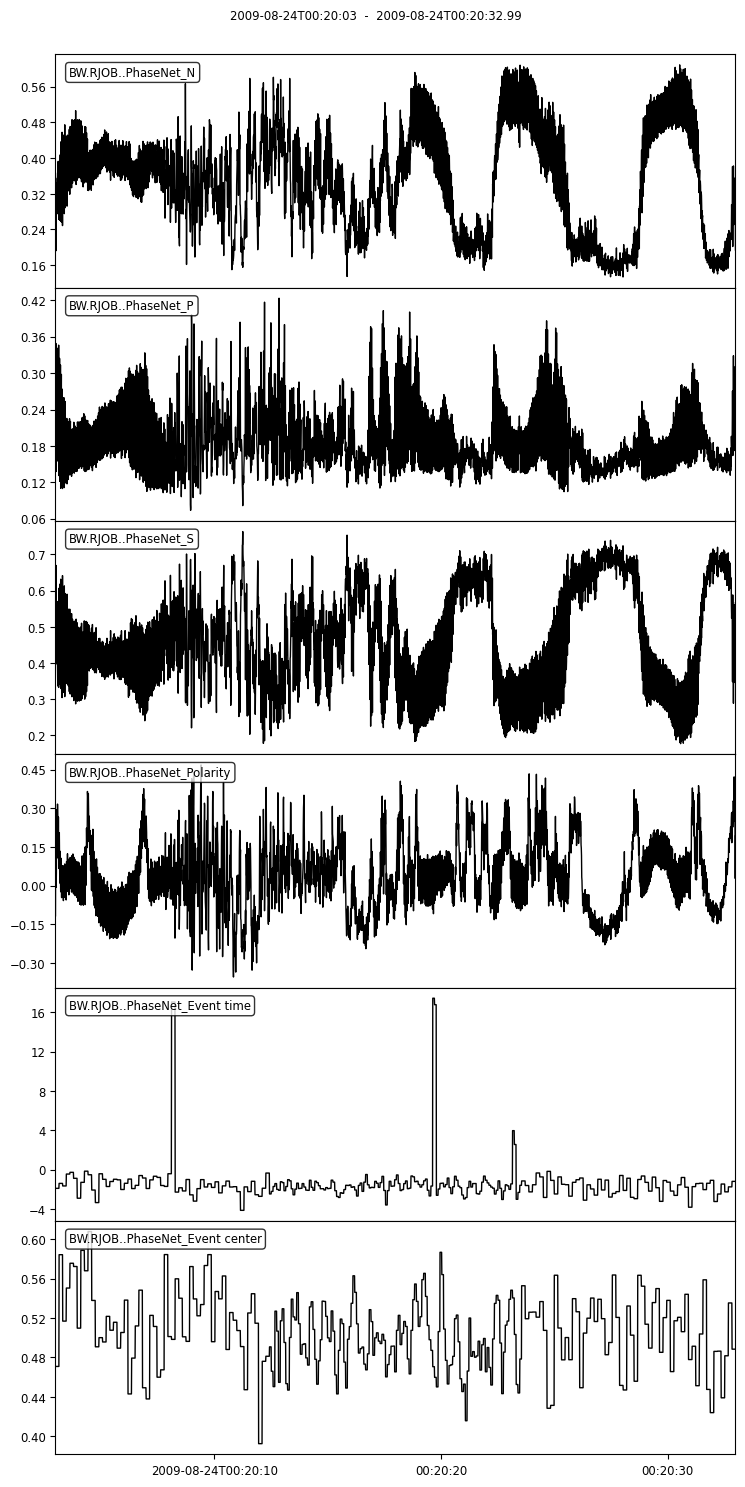

In [14]:
ann.plot(equal_scale=False);

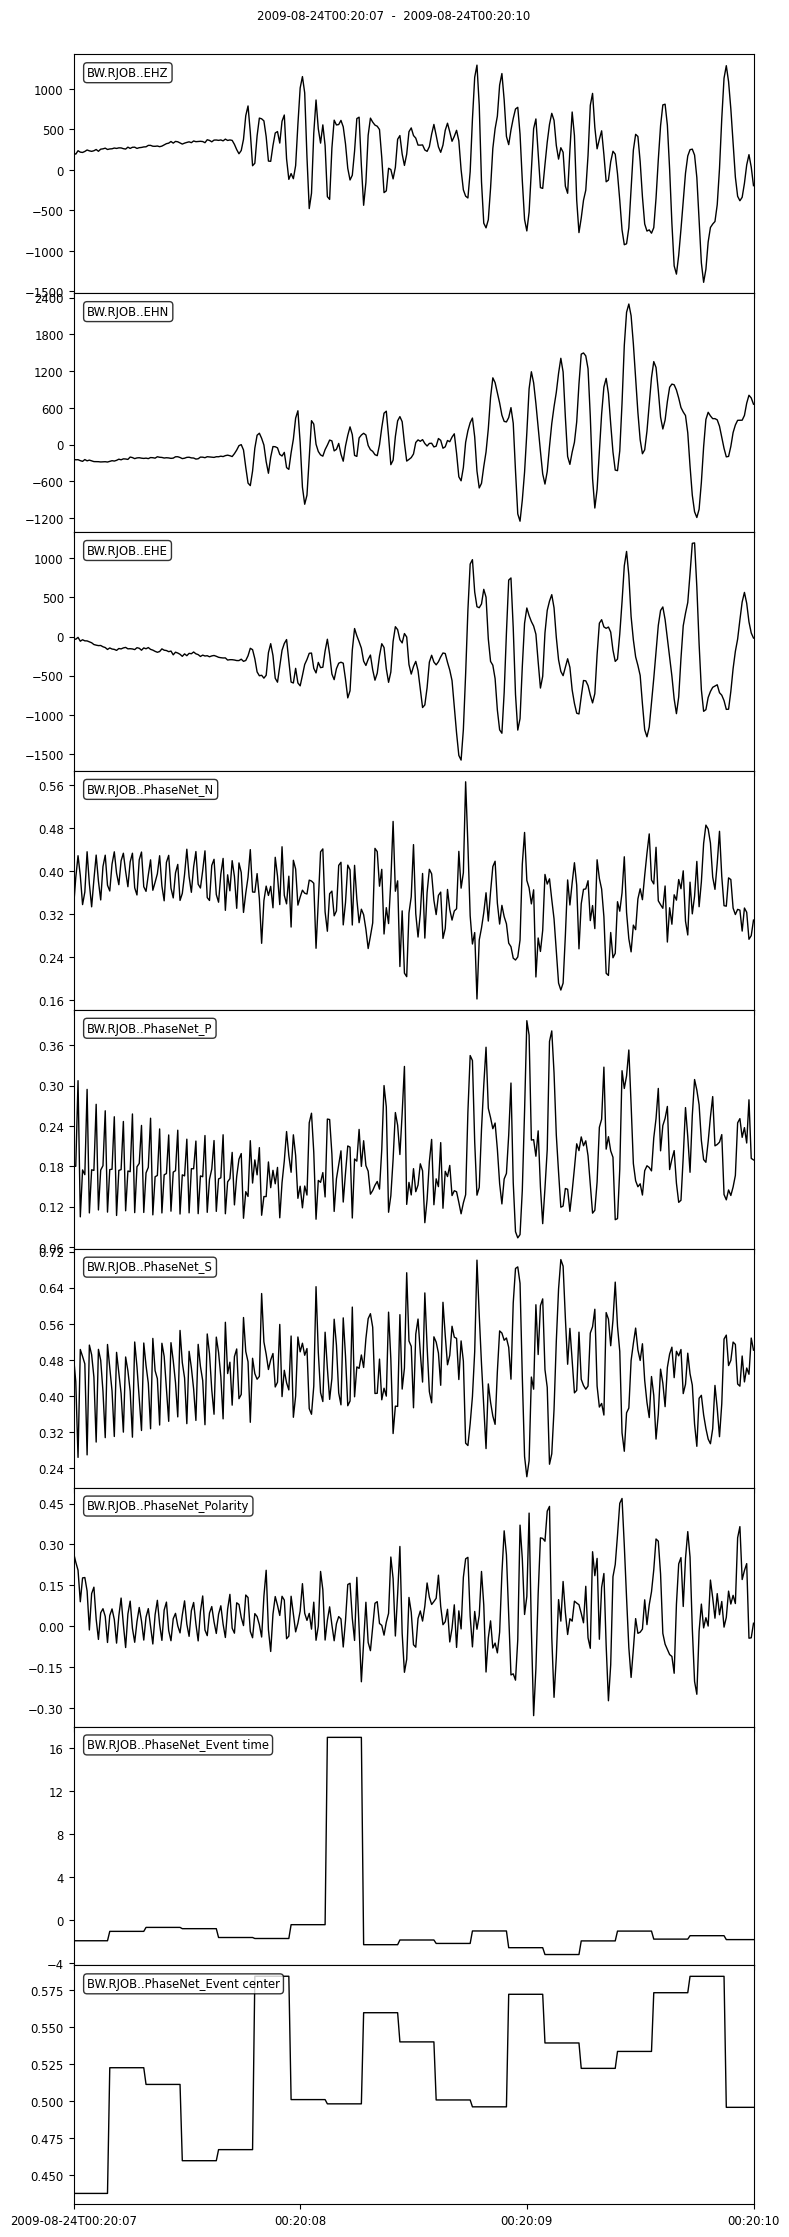

In [15]:
t = stream[0].stats.starttime
(stream + ann).slice(t + 4, t + 7).plot(equal_scale=False);

In [18]:
stream_filtered = stream.copy().filter("highpass", freq=1)
ann_sub = ann.select(channel="*_P") + ann.select(channel="*_S")

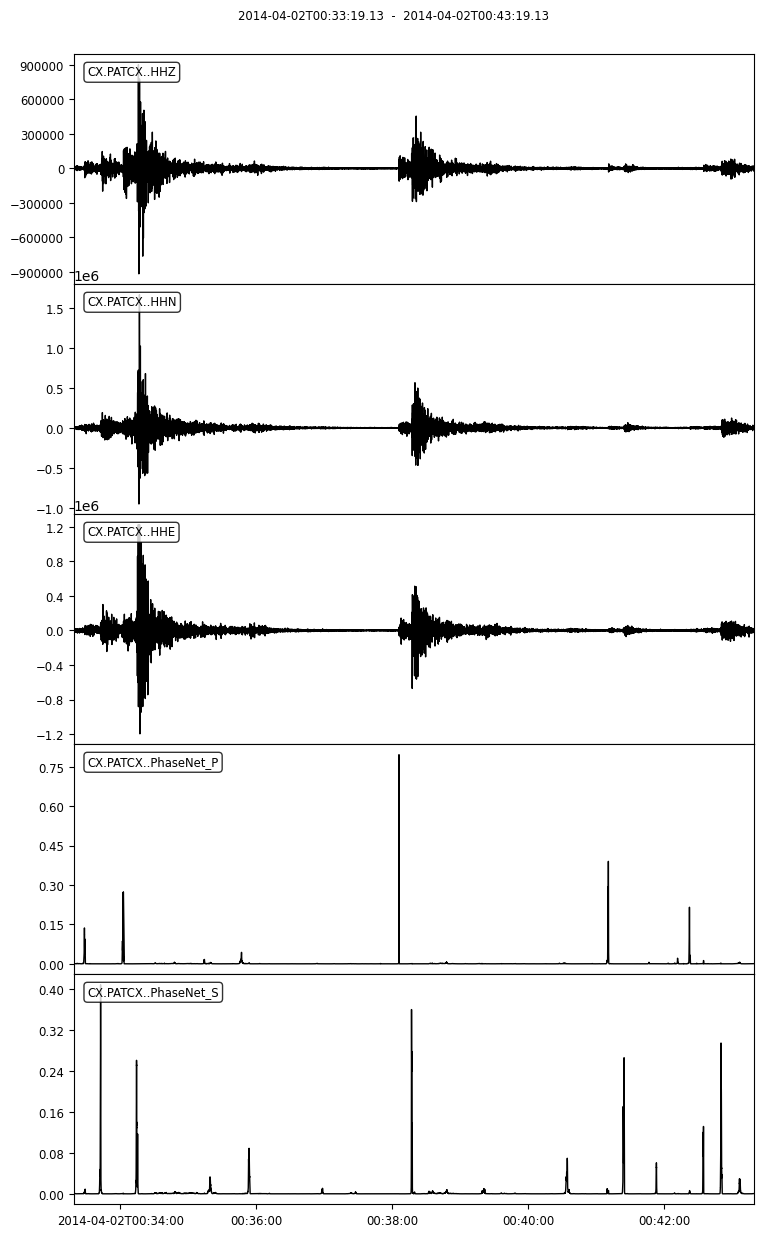

In [21]:
w = 600
t = stream[0].stats.starttime + 2000

(stream_filtered + ann_sub).slice(t, t + w).plot(equal_scale=False);